# EDA titanic (seaborn) classification


## Imports

In [1]:
### library/modules = toolbox

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = sns.load_dataset('titanic')

In [3]:
display(data.head(3))
display(data.tail(4))


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### context:
- pclass: passager class
- sibsp: "sibling-spouse"
    - how many other passager came with him/her that are either a sibling or a spouse
- parch : "parent-children"
    - similar to sibsp

- fare: price
- deck:
    - the "region" in boat, associated to the cabin (numbers)
    - lots of missing values (dormatory where present-> no cabin ?)


## utilities

In [4]:
def give_INFO(data:pd.DataFrame,sample=False)-> pd.DataFrame:
    
    columns = ['dtypes','nunique','isna_sum']
               #,'sample1','sample2','sample3'] 
    
    DF = pd.concat([data.dtypes,data.nunique(),data.isna().sum()],axis=1)
    DF.columns = columns
    
    
    if sample:
        DF['sample1'] = data.sample().T # sample = 1 random line in dataset
        DF['sample2'] = data.sample().T
        DF['sample3'] = data.sample().T
    
    DF.reset_index(inplace=True)
    return DF


def show_null(data:pd.DataFrame)-> pd.DataFrame:
    
    plt.figure(figsize=(10, 5))

    plt.title('Missing Values\n')

    sns.heatmap(data.isnull(), cbar=False)
    plt.show()

    data.isnull().sum()
    pass

# EDA: Exploratory Data Analysis
- do this before any machine learning project
- understand the data
- know what to transform/modify for the ML

## 1. Format-analysis

- analysis of metadata


In [5]:
data.info()

display(give_INFO(data))
print('data.shape=',data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,index,dtypes,nunique,isna_sum
0,survived,int64,2,0
1,pclass,int64,3,0
2,sex,object,2,0
3,age,float64,88,177
4,sibsp,int64,7,0
5,parch,int64,7,0
6,fare,float64,248,0
7,embarked,object,3,2
8,class,category,3,0
9,who,object,3,0


data.shape= (891, 15)


### data types:

- see if definition/context of column matches with a datatype that is expected
    - possible optimisation if current datatype is too big, but compatible with expectation
    - possible heavy transformation ahead if we got an alphanumerical,while the expectation was only a numerical
    - categorical columns with lots of unique values require more transformation than categrories with few uniques


### missing values:
- having an idea on what is the distribution of missing data throughout the dataset, can inform us on the best strategy to process those for machine learing:
- having only a few columns with lots of missing data is different from blocks of rows with missing data, which is also different from random missing values everywhere

- simple strategies to illustrate: (= ultimately this choice depend on context, and should not be automated away !)
    - mainly few columns with missing values : drop column, create new boolean column "is_col_empty"
    - mainly few rows with missing values: drop rows
    - mix between both: replace values with standard ones (median, mode,...)


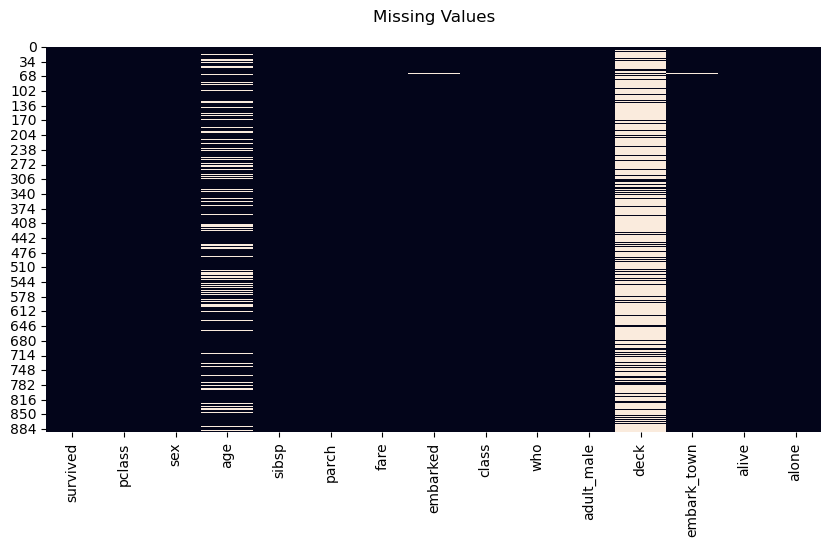

In [6]:
show_null(data)

## 2. Univariate content-analysis

- not the most interesting analysis, but allows to verify:
    - if all columns have an appropriate datatype (for their expected statistical type)
    - if there are extreme values
    - if there are unbalanced frequencies


### 2.a. Target analysis
- for both for analysis and machine learning, a lot of decisions will heavily depend on:
    - what is the statistical type of the target
    - distribution of the target 



In [7]:
### referencing for systematic use of this template
target = 'survived'


In [8]:
data[target].unique()

array([0, 1])

In [9]:
#data[target] = data[target].astype('category')

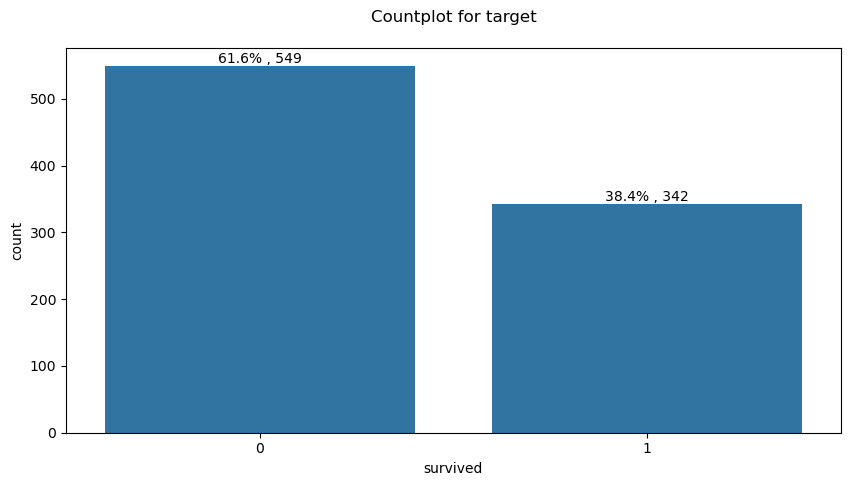

In [10]:
### recommendations:
### if the column is a categorical variable: -> barplot for visualisation
### if the column is a numerical variable: -> histogram for visualisation


plt.figure(figsize=(10, 5))
plt.title('Countplot for target\n')

col = target

ax = sns.countplot(data=data, x=col) # countplot = barplot + count

N_tot = data[col].count()

### show the data-labels for each bar
for container in ax.containers:
    ## https://stackoverflow.com/questions/31749448/how-to-add-percentages-on-top-of-grouped-bars
    ##labels = [f'{h/N_tot*100:0.1f}% , {int(h)}' if (h := v.get_height()) > 0 else '' for v in container]
    
    
    labels = [] 
    ## container =  group of bars,
    ## vbar =  bar of group of bars 
    for vbar in container:
        h = vbar.get_height()
        ### show (percentage vs total) and (count)
        str_ = f'{h/N_tot*100:0.1f}% , {int(h)}' if h>0 else ''
        labels.append(str_)
        
    ax.bar_label(container, labels=labels, label_type='edge')

    #ax.bar_label(container) #simply add count

plt.show()



### show same info but in a table/list/series
#print(data[col].value_counts()/data[col].count())

### 2.b. Features analysis: setup

In [11]:
feat_cols = data.columns.to_list()
feat_cols.remove(target)

In [12]:
feat_cols

['pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

## some feature engineering
- those transformation allows to make more complete graphs for analysis
- (here it is done in advance, but in practice we don't know until it becomes apparent/relevant)

In [13]:
data["has_deck"] = data["deck"].notnull()
data['deck'] = data['deck'].astype(str) ## allows to add "nan" as an additional category


In [14]:

### VERY CRITICAL input from user !!!

### segregation of features into relevant groups of statistical variables

### ordinal_categorical
ord_cols = ['pclass','class',]

### nominal_categorical
nom_cols = ['sex','embarked','who','adult_male','deck','embark_town','alive','alone']+['has_deck']


### discrete_numerical

dis_cols = ['sibsp','parch',]

### continuous_numerical
con_cols = ['age','fare']


### ------------ ###
### all categorical together
cat_cols = ord_cols + nom_cols 

### all numerical together
num_cols = dis_cols+con_cols


### raise error when (condition not met), (comment of error)
#assert len(num_cols)+len(cat_cols) == len(feat_cols), 'non-matching elements'


### 2.c. Categorical features

In [15]:
cat_cols

['pclass',
 'class',
 'sex',
 'embarked',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'has_deck']

In [16]:
def give_countplots(data:pd.DataFrame,cols:list,hue=None):
    '''provide a picture of subgraphs of countplots
        for each column in 'cols'
        decomposed/grouped by 'hue'
    '''
    N_cols = len(cols)
    DF = data.loc[:,cols] if hue is None else data[[hue]+cols]
    
   
    
    fig = plt.figure(figsize=(10, 5*N_cols))
    
    for i,col in enumerate(cols):
        plt.subplot(N_cols,1,1+i)
        '''
        if hue is not None:
            plt.title(f'Countplot for {col} by hue = {hue}\n')
        else:
            plt.title(f'Countplot for {col}\n')
        ''' 
        ax = sns.countplot(data=DF, x=col, hue=hue) 

        N_tot = DF[col].count()

        ### show the data-labels for each bar
        for container in ax.containers:
            ## https://stackoverflow.com/questions/31749448/how-to-add-percentages-on-top-of-grouped-bars
            ##labels = [f'{h/data[target].count()*100:0.1f}%' if (h := v.get_height()) > 0 else '' for v in container]


            labels = [] 
            for vbar in container:
                h = vbar.get_height()

                ## add % and count
                str_ = f'{h/N_tot*100:0.1f}% , {int(h)}' if h>0 else ''
                labels.append(str_)

            ax.bar_label(container, labels=labels, label_type='edge')
        plt.xticks(rotation=90)
        plt.tight_layout()
    plt.show()
    return 

    

In [17]:
def give_proportion_plot(data:pd.DataFrame,cols:list,target:str,hue=None,invert=False):
    
    N_cols = len(cols)
    
    fig = plt.figure(figsize=(10, 5*N_cols))
    for i,col in enumerate(cols):
        plt.subplot(N_cols,1,1+i)
        GB = data.groupby([col,target],as_index=False, observed=True).agg(count=(target,"count"))
        GB_cond_target = data.groupby([target], as_index=False,observed=True).agg(N_target=(target,"count"))
        GB_cond_feat = data.groupby([col],as_index=False,observed=True).agg(N_feat = (target,"count"))
        
        
        GB_ = GB.merge(GB_cond_target, on = target).merge(GB_cond_feat, on=col)

        GB_["P(X|target)"] = GB_["count"]/GB_["N_target"]
        GB_["P(target|X)"] = GB_["count"]/GB_["N_feat"]

        if hue:
            
            if not invert:
                
                ax = sns.barplot(data= GB_, y='P(X|target)',x=col,hue=target)
            else:
                ax = sns.barplot(data= GB_, y='P(target|X)',x=col,hue=target)
        else:
            ax = sns.countplot(data=data, x=col, stat="proportion")
            
        for container in ax.containers:
            ## https://stackoverflow.com/questions/31749448/how-to-add-percentages-on-top-of-grouped-bars
            ##labels = [f'{h/data[target].count()*100:0.1f}%' if (h := v.get_height()) > 0 else '' for v in container]


            labels = [] 
            for vbar in container:
                h = vbar.get_height()

                ## add % and count
                str_ = f'{h:0.2f}' if h>0 else ''
                labels.append(str_)

            ax.bar_label(container, labels=labels, label_type='edge')
        plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    return 

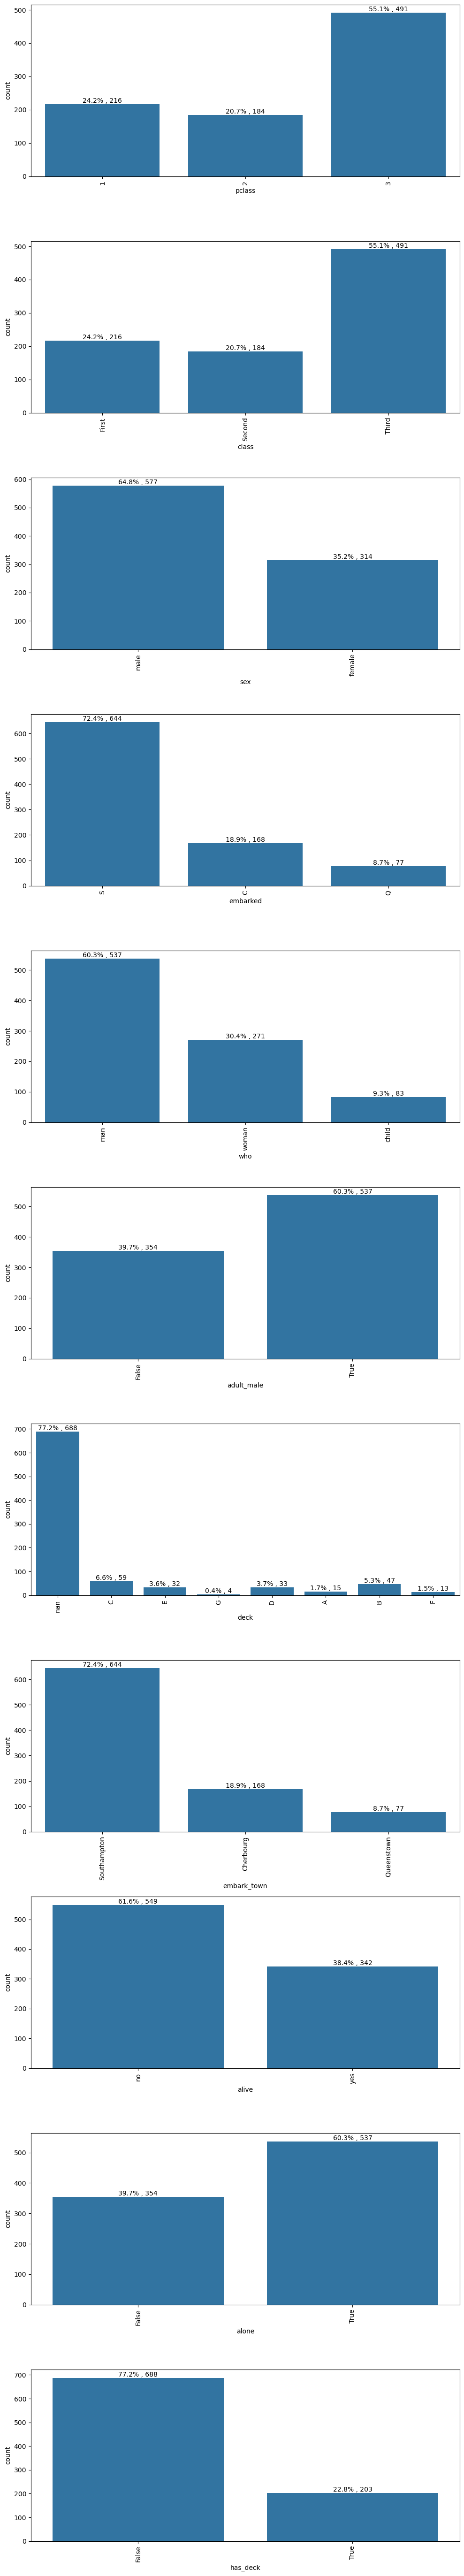

In [18]:
fig = give_countplots(data,cat_cols,hue=None)

In [19]:
display(data[cat_cols].astype('category').describe().T)

,count,unique,top,freq
pclass,891,3,3,491
class,891,3,Third,491
sex,891,2,male,577
embarked,889,3,S,644
who,891,3,man,537
adult_male,891,2,True,537
deck,891,8,nan,688
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


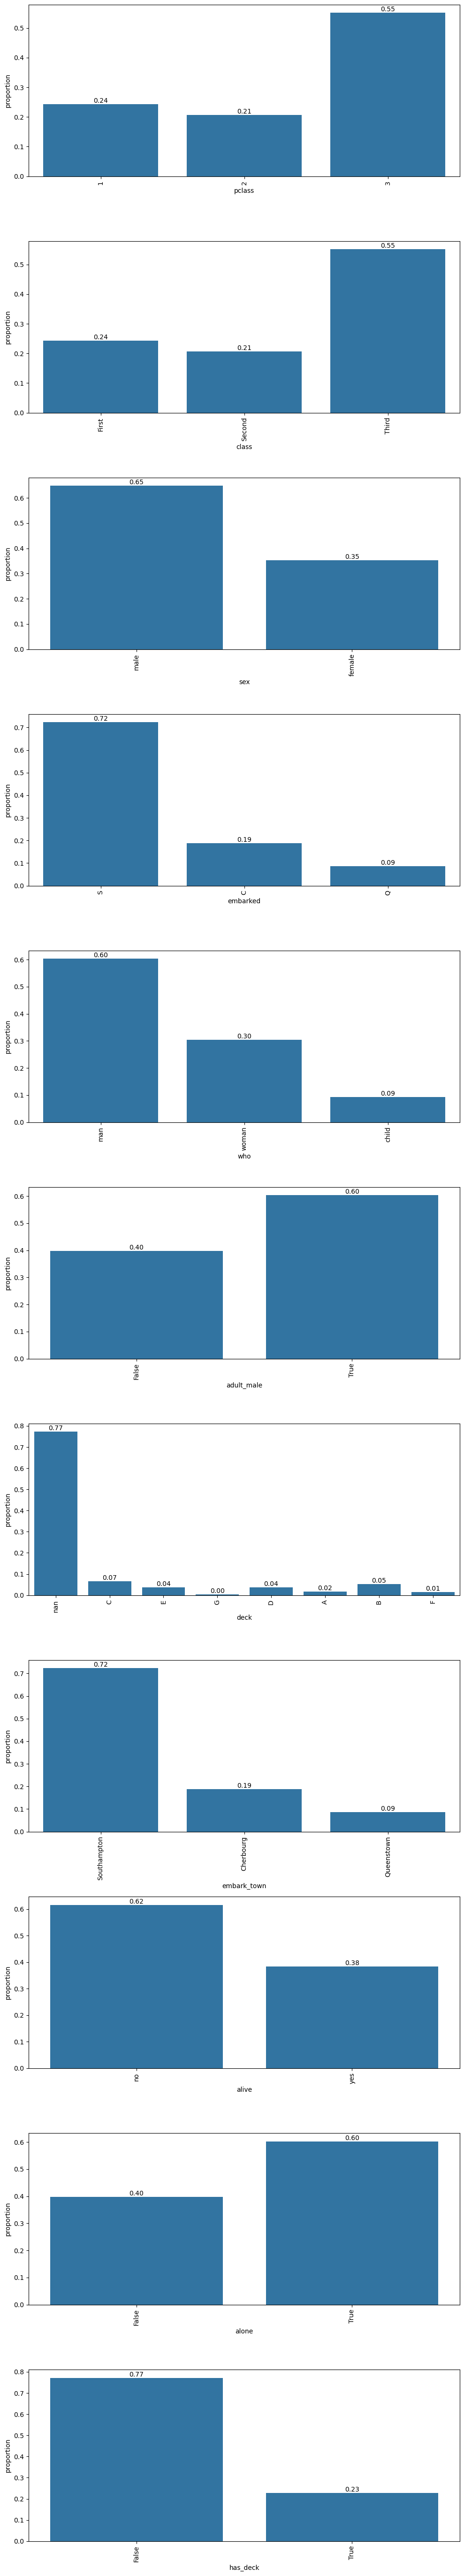

In [20]:
give_proportion_plot(data=data,cols=cat_cols,target=target)

### 2.d. Numerical features

In [21]:
num_cols

['sibsp', 'parch', 'age', 'fare']

In [22]:
def give_histplots(data:pd.DataFrame,cols:list,hue=None,
                   stat='count',common_norm=True, discrete=False):
    '''histplots of columns in 'cols' decomposed by 'hue'
        stat = 'count', 'percent', 'density' , ... --> see doc seaborn for histplot
        discrete =  each occurence is a bin --> see doc seaborn for histplot
        
        common_norm = if false: when decomposed by 'hue'
            => use groupby(hue) count as ref --> see doc seaborn histplot 
    '''
    N_cols = len(cols)
    DF = data[cols] if hue is None else data[[hue]+cols]
    
    
    fig = plt.figure(figsize=(10, 5*N_cols))
    
    for i,col in enumerate(cols):
        plt.subplot(N_cols,1,1+i)
        '''
        if hue is not None:
            plt.title(f'Countplot for {col} by hue = {hue}\n')
        else:
            plt.title(f'Countplot for {col}\n')
        ''' 
        sns.histplot(data=DF, x=col
                      , fill=True
                      #, element="step" #
                      , stat = stat#'count' # 'count','density','percent', ...
                      , discrete=discrete
                      , kde= not discrete
                      , common_norm=common_norm
                      , hue = hue
                     )

        
        plt.tight_layout()
    
    return fig
    
    

In [23]:
dis_cols

['sibsp', 'parch']

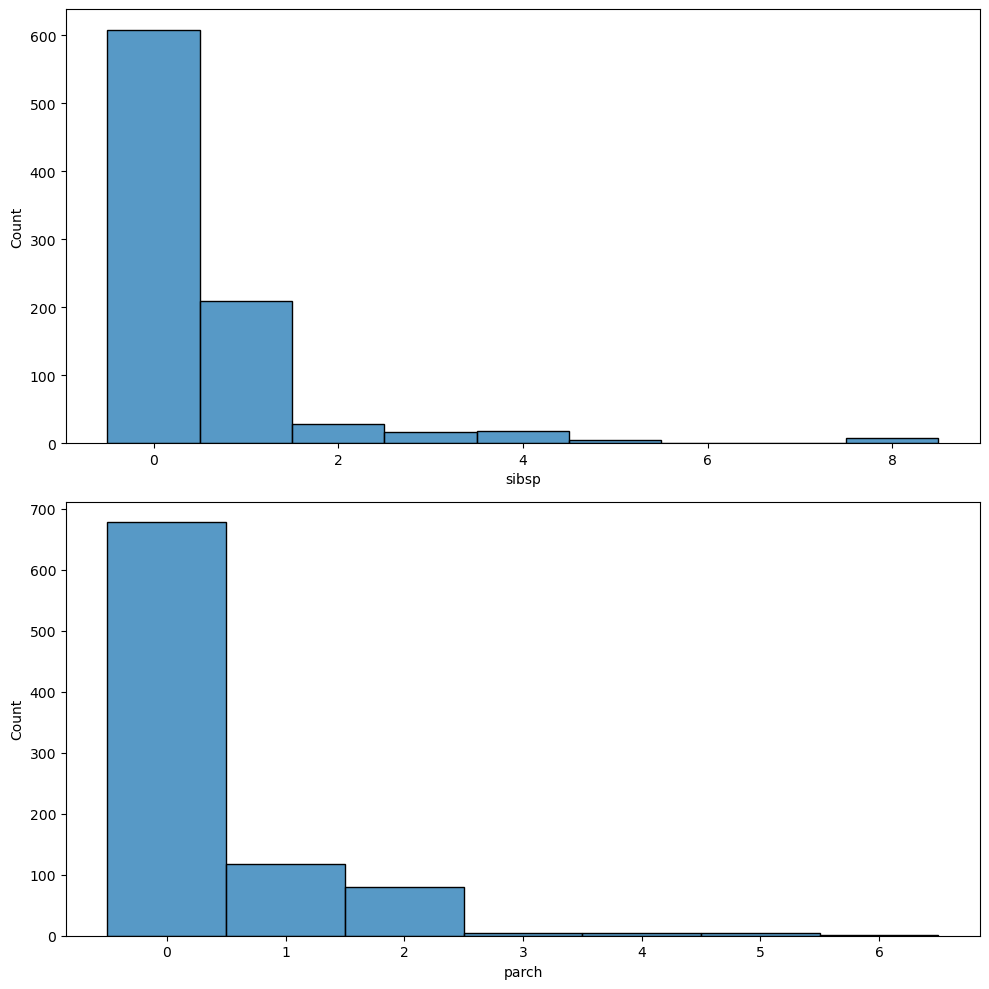

In [24]:
fig = give_histplots(data,dis_cols,discrete=True)

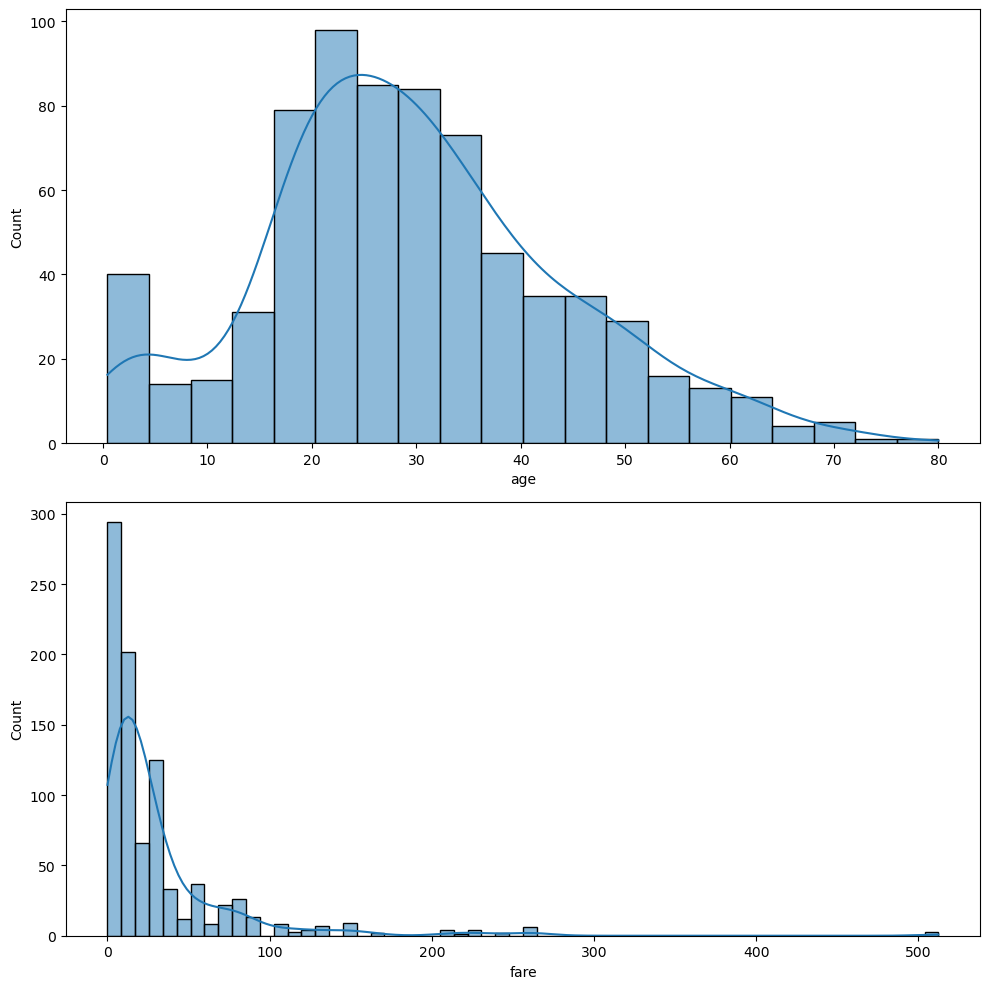

In [25]:
fig = give_histplots(data,con_cols)

In [26]:
#sns.countplot(data,x="fare") ## wrong graph


In [27]:
display(data[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### 2.e. feature engineering for problematic columns discovered in univariate analysis (or before)

## 3. Bivariate content analysis: features vs target

- Bivariate analysis allows us to analyze two columns.
- In this case, we want to know which columns are most relevant for predicting passengers survival.
    - Here, we will combine each feature with the "survived" column.
- We can also perform the analysis on any combination of columns.



## 3.a.  Categorical vs target


recommendations:  
__feature vs target:__
- _categorical vs categorical:_  
        barplot/countplot/pie-chart of feature,  
        color/hue based on target values  
        
        groupby(target)

- _categorical vs numerical:_  
        histogram of target,  
        color/hue based on feature   
        
        groupby(feature)

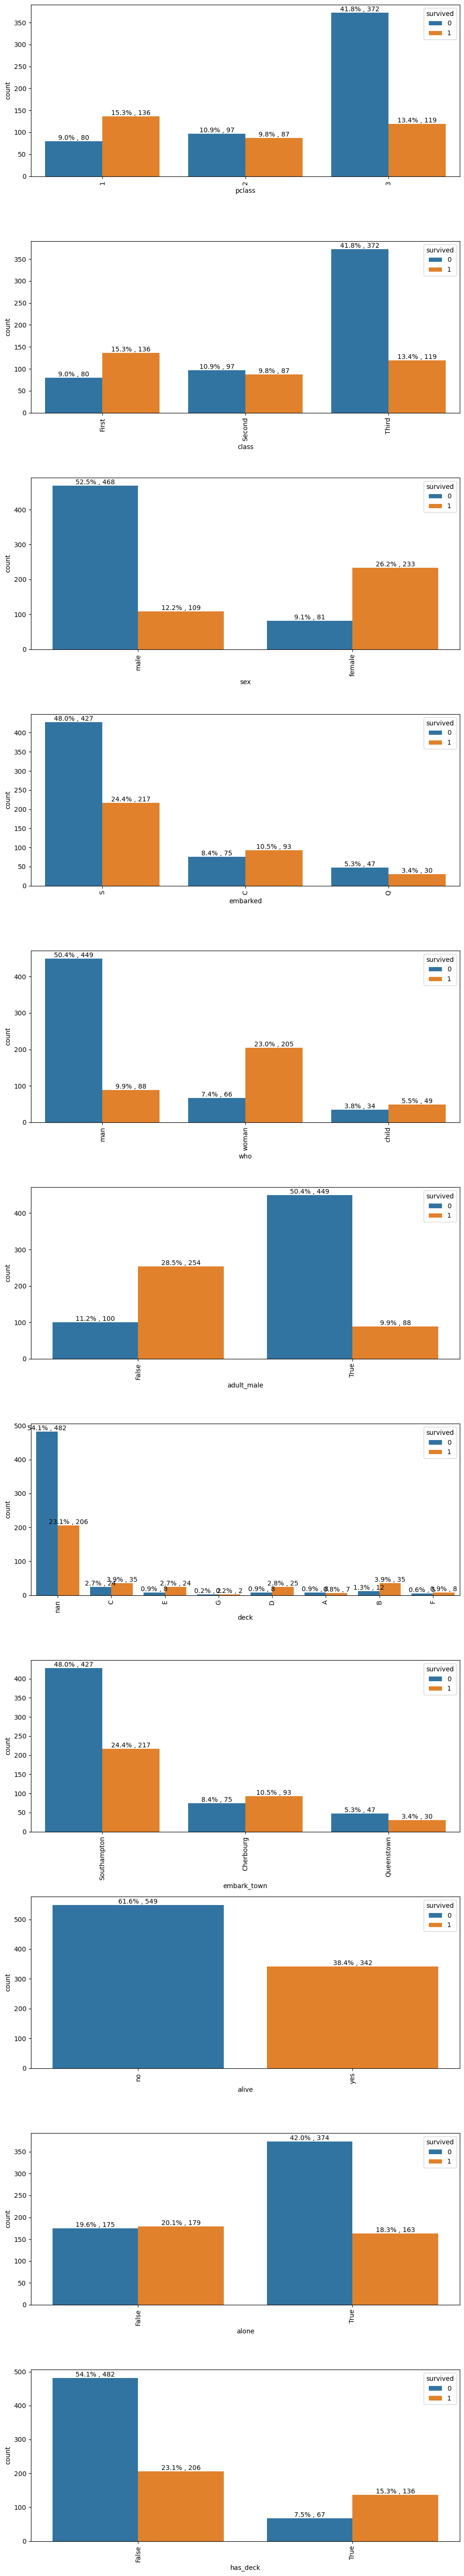

In [28]:
fig = give_countplots(data, cat_cols, hue=target)

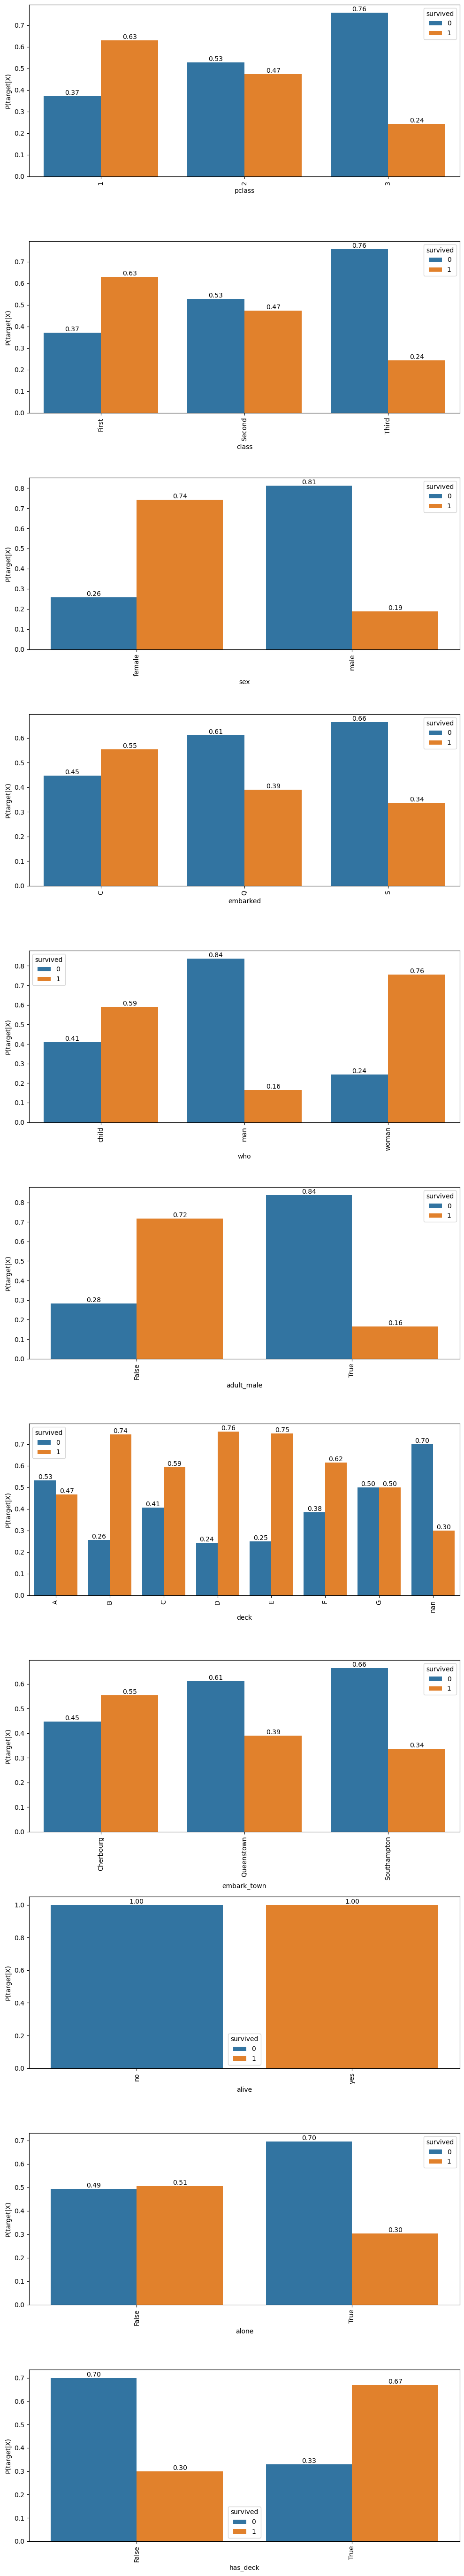

In [29]:
give_proportion_plot(data,cat_cols,hue=target, invert=True,target=target)

## 3.b. Numerical vs target


recommendations:  
__feature vs target:__
- _numerical vs categorical:_  
        histogram of feature,  
        color/hue based on target 
        
        groupby(target)
    

- _numerical vs numerical:_  
        scatter/pair plot with 
        feature on x-axis, target on y-axis
        
        no groupby

In [30]:
dis_cols

['sibsp', 'parch']

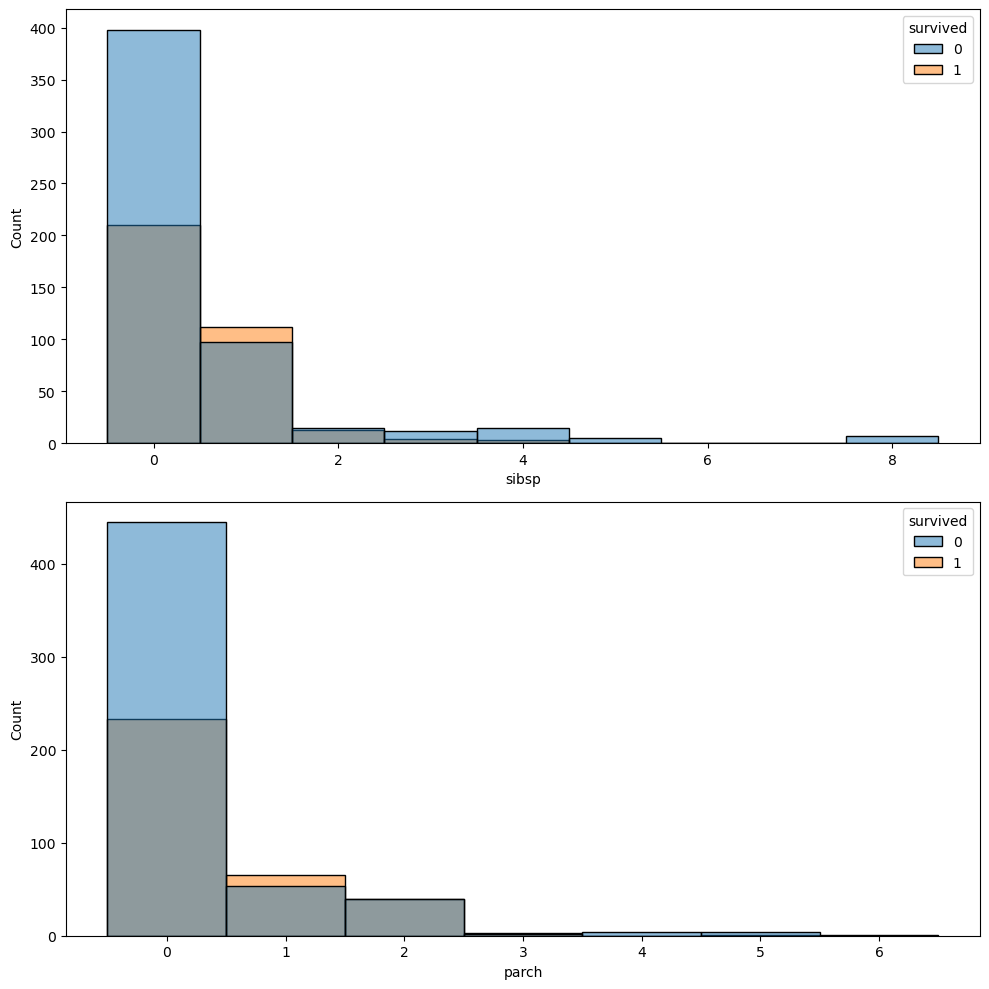

In [31]:
fig = give_histplots(data,dis_cols,discrete=True,hue=target)

In [32]:
con_cols

['age', 'fare']

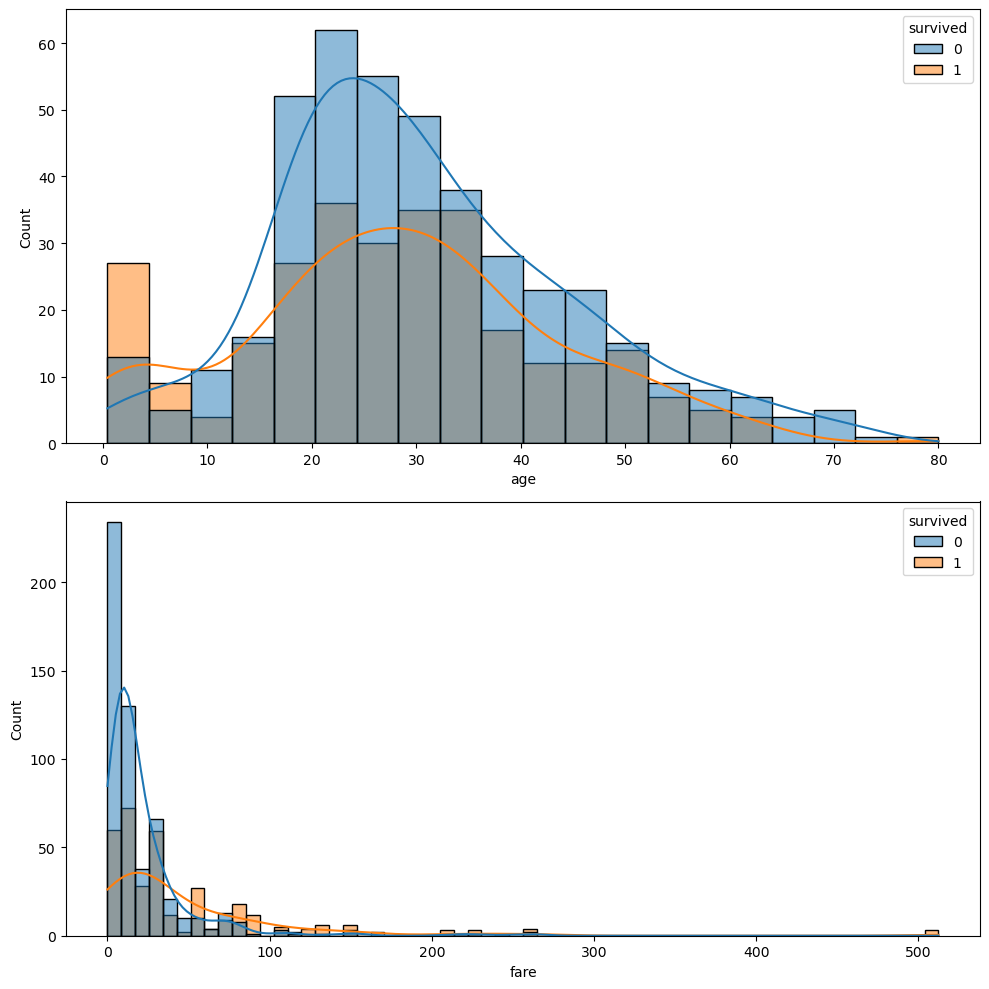

In [33]:
fig = give_histplots(data,con_cols,hue=target)

### relative proportions
- for unbalanced data, it might be more relevant to compare relative proportions instead of absolute values

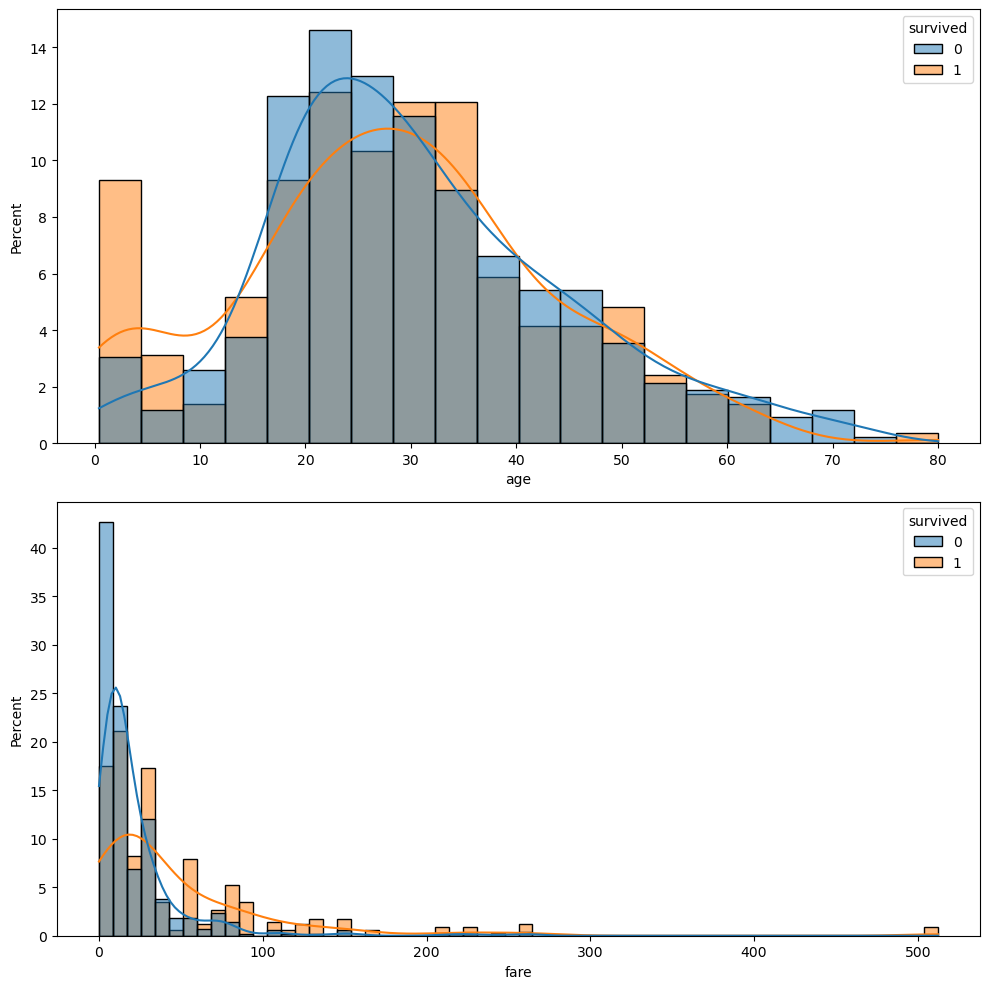

In [34]:
## relative percentage: conditional relative frequency (frequences conditionelles)

fig = give_histplots(data,con_cols,hue=target,common_norm=False,stat='percent')

In [35]:
### groupby-statistics
if False:
    for col in num_cols:
        display(data[[col,target]].groupby(target).describe())

## 3.c. Correlations

Only works with numbers!

- Method:
    - "Pearson": "linear": covariance, Gaussian -> only on numerical columns
    - "Spearman": "monotonic": covariance on ranks/order -> also applicable to "ordinal" columns

- caution: it is more prudent not to over-compare the degrees of correlation between different combinations; these figures should be seen as an indication of a "linear"/"monotonic" relationship
    - "numerical" vs. "numerical"
    - "numerical" vs. "category"
    - "category" vs "category"

- When columns need to be removed for performance reasons, we look for two things:
    1. We do not want to remove features that are strongly correlated with the target (in this case, "survived").
    2. We want to remove features that are strongly correlated with each other.




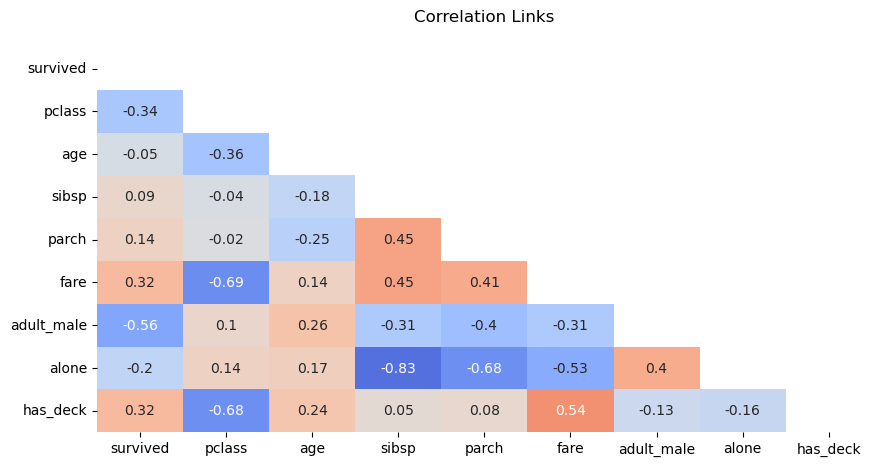

In [36]:
corr_init = data.corr(method='spearman',numeric_only=True).round(2)

mask = np.triu(np.ones_like(corr_init, dtype=bool))

### put the same info in a graph
plt.figure(figsize=(10, 5))
plt.title('Correlation Links\n')


### heatmap with symetric table
sns.heatmap(data = corr_init,
            vmin=-1,
            vmax=1,
            cmap='coolwarm',
            cbar=False,
            annot=True,
            mask=mask, #mask == hide values
           )
plt.show()


In [37]:
data_dumm = pd.get_dummies(data)
display(data_dumm.head())

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,has_deck,sex_female,...,deck_D,deck_E,deck_F,deck_G,deck_nan,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,alive_no,alive_yes
0,0,3,22.0,1,0,7.2500,True,False,False,False,...,False,False,False,False,True,False,False,True,True,False
1,1,1,38.0,1,0,71.2833,False,False,True,True,...,False,False,False,False,False,True,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,False,True,...,False,False,False,False,True,False,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,True,True,...,False,False,False,False,False,False,False,True,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,False,...,False,False,False,False,True,False,False,True,True,False


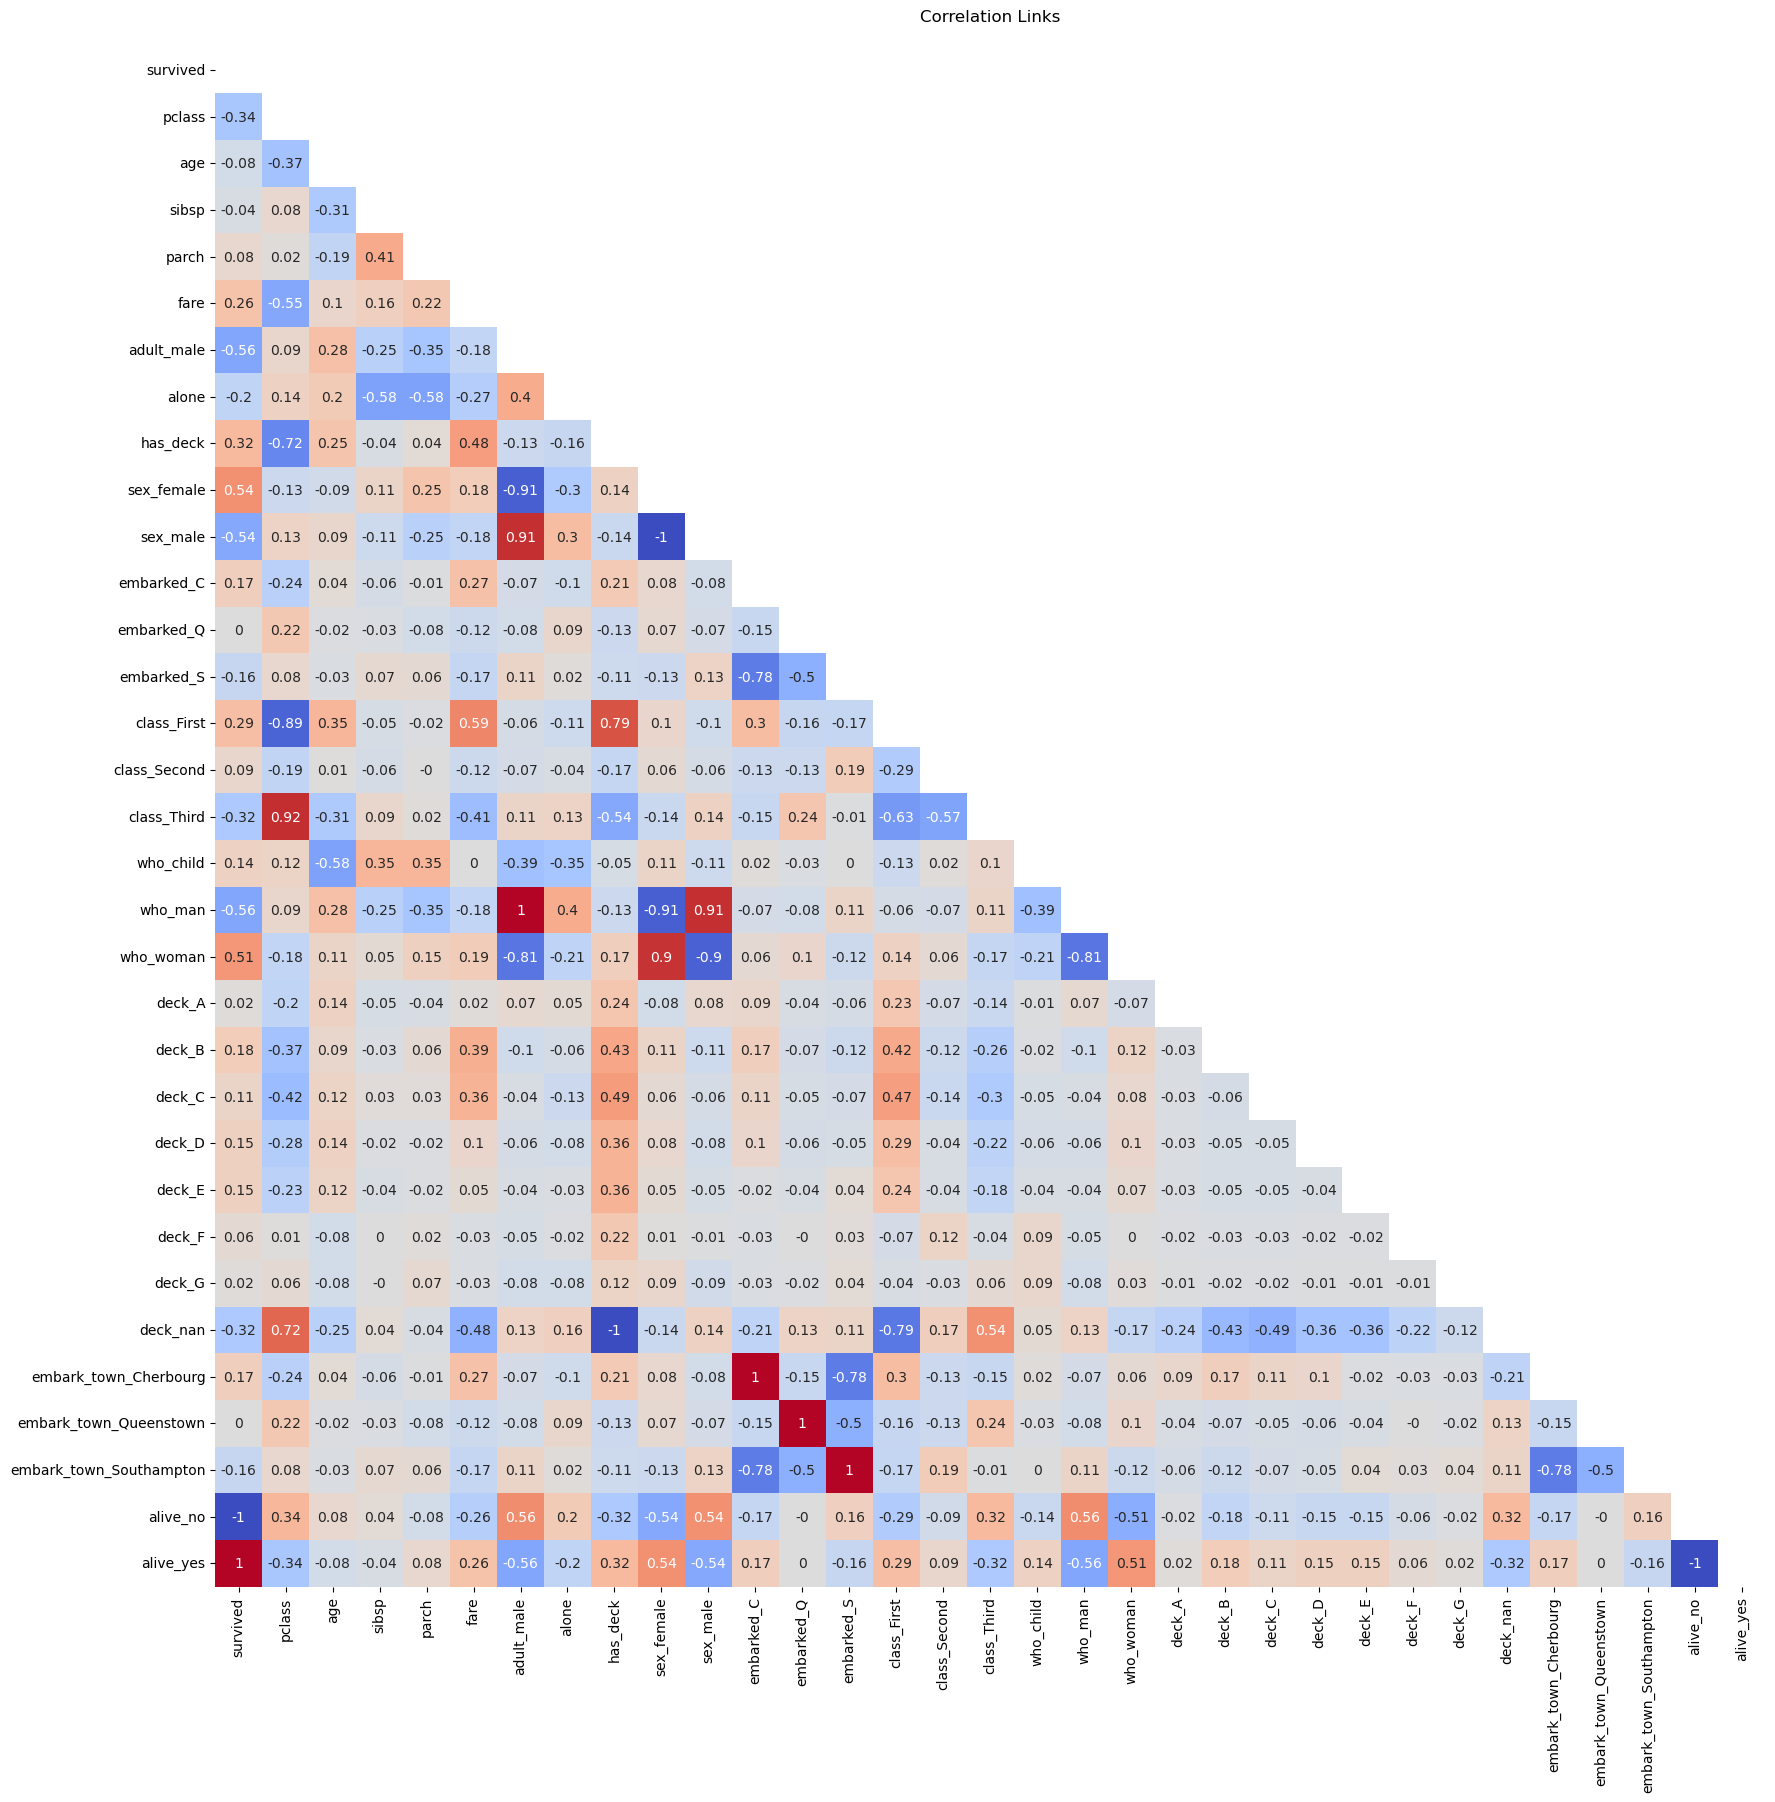

In [38]:
corr_init = data_dumm.corr(numeric_only=True).round(2)

mask = np.triu(np.ones_like(corr_init, dtype=bool))

### put the same info in a graph
INCH = 20
plt.figure(figsize=(INCH,INCH))
plt.title('Correlation Links\n')


### heatmap with symetric table
sns.heatmap(data = corr_init,
            vmin=-1,
            vmax=1,
            cmap='coolwarm',
            cbar=False,
            annot=True,
            mask=mask, #mask == hide values
           )
plt.savefig('titanic_corr.pdf')
plt.show()

## 4. Multivariate content analysis
recommendations:

 - try pairplot where applicable
 - groupby where applicable

 - violinplot
>there are no additional general recommendations,
    it depends mostly on context/meaning of the columns

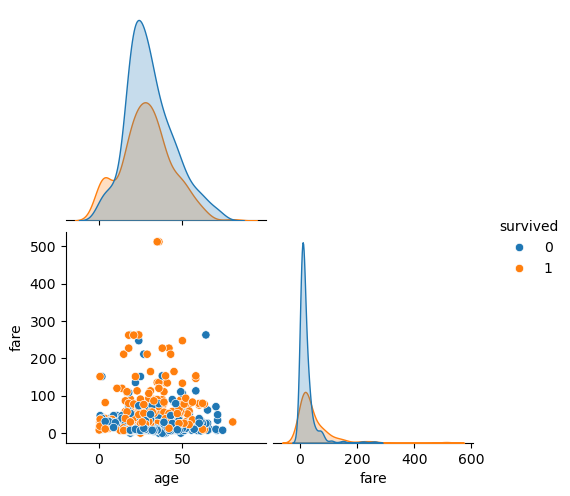

In [39]:
if True:
    ### the following pairplot provides a bunch of scatter plot between 
    ### all the combinations of2 numerical features,
    ### while the color depends on the target values

    sns.pairplot(data=data[[target]+con_cols], hue=target, corner =True) #target categorie => hue = target

    plt.savefig('pairplot_titanic.pdf', dpi=300)
    plt.show()

In [40]:
(data.columns.to_list())

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'has_deck']

In [42]:
# ================================================ #
### !!! UN SIMPLE GROUP BY EST TRÈS EXPRESSIF !!!
# ================================================ #
GB = data[[target
            ,'adult_male'
            ,'pclass'
            ,'age'
           ]].groupby(['adult_male'
                       ,'pclass'
                      ],as_index=False).agg({'age':'mean'
                              ,target:['sum','count','mean']
                             })
GB = GB.sort_values(by=[('survived','mean')],ascending=False)#.reset_index()
GB

adult_male pclass        age survived                
                          mean      sum count      mean
0      False      1  33.612727       94    97  0.969072
1      False      2  25.853373       79    85  0.929412
2      False      3  18.468615       81   172  0.470930
3       True      1  42.382653       42   119  0.352941
5       True      3  28.995556       38   319  0.119122
4       True      2  33.588889        8    99  0.080808

In [43]:
GB = data[[target
            ,'sex'
            ,'pclass'
            ,'who'
            ,'alone'
            ,'age'
           ]].groupby(['sex'
                       ,'pclass'
                       ,'who'
                       ,'alone'
                      ]).agg({'age':'mean'
                              ,target:['sum','count','mean']
                             })
GB = GB.sort_values(by=[('survived','mean')],ascending=False).reset_index()
GB

sex pclass    who  alone        age survived                
                                      mean      sum count      mean
0   female      2  child  False   6.600000       10    10  1.000000
1     male      1  child  False   5.306667        3     3  1.000000
2     male      2  child  False   2.258889        9     9  1.000000
3   female      1  woman  False  35.860000       56    57  0.982456
4   female      1  woman   True  34.937500       33    34  0.970588
5   female      2  woman  False  31.117647       31    34  0.911765
6   female      2  woman   True  33.383333       29    32  0.906250
7   female      3  child   True  12.400000        4     5  0.800000
8   female      1  child  False  10.333333        2     3  0.666667
9   female      3  woman   True  25.257576       33    55  0.600000
10  female      3  child  False   6.040000       12    25  0.480000
11  female      3  woman  False  30.051282       23    59  0.389831
12    male      1    man  False  39.659091       17    44  0.386364
13    male      1    man   True  44.601852       25    75  0.333333
14    male      3  child  False   6.348889        9    27  0.333333
15    male      3    man   True  29.282258       32   263  0.121673
16    male      3    man  False  27.628205        6    56  0.107143
17    male      2    man   True  33.904762        7    72  0.097222
18    male      2    man  False  32.851852        1    27  0.037037
19    male      3  child   True  11.000000        0     1  0.000000

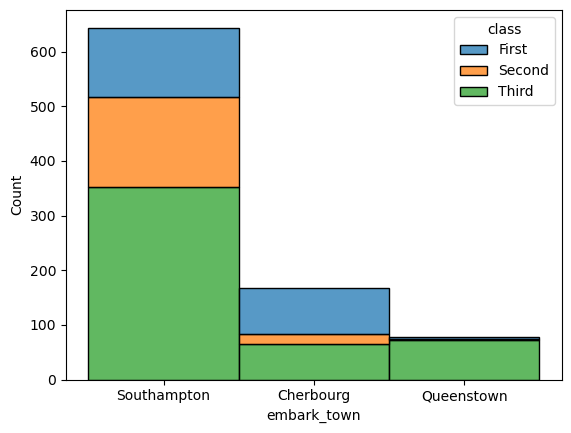

In [44]:
sns.histplot(data
             ,x='embark_town'
             ,hue='class'
             ,discrete=True
             , multiple='stack'
            )
plt.show()

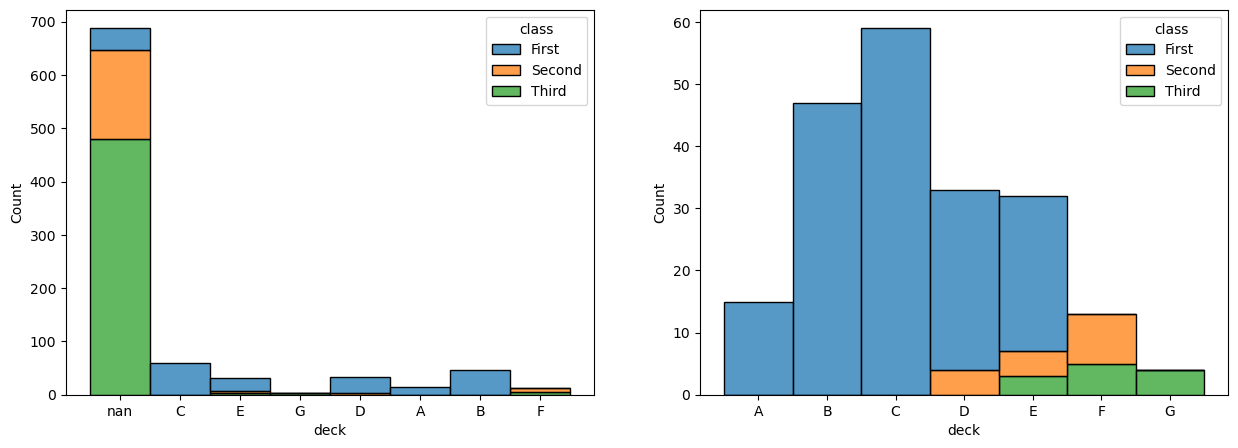

In [45]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data
             ,x='deck'
             ,hue='class'
             ,discrete=True
             , multiple='stack'
            )

plt.subplot(1,2,2)

sns.histplot(data.loc[data['deck']!='nan',:].sort_values(by='deck', ascending=True)
             ,x='deck'
             ,hue='class'
             ,discrete=True
             , multiple='stack'
            )
plt.show()